<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:25px;
          font-weight: bold">
          Mandatory Assignment
    
</p>

<img src="https://www.jircas.go.jp/sites/default/files/styles/4_3/public/202110/20211001_ico.png?itok=JZAwGcQB">

<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Introducing The Problem
    
</p>

**Our dataset
Table of content:**
1. Introducing the Problem
2. Description of the data
3. Creating the Dataset
4. Visualization
5. Analysis

    a. Basic statistics
    
    b. Ordinarily Squares
    
    c. Machine Learning
6. Results
7. Discussion
8. Future Research

<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Description Of The Data
    
</p>

**Problem Thesis**

We live in a world which is divided, with split priorities depending on where we live, and the society we share. We are therefore exploring the possibility of predicting future GDP per capita, based on data of the sustainability goals gathered by the UN.  

**Data decription**

In this assignment, we will use the 17 Sustainable Development Goals to predict the GDP (Gross Domestic Product) in a country. The chosen datasets to analyze this are the “Sustainable Development Data up to 2023” and the “World GDP(GDP per capita)”, both from Kaggle. The supplementary datasets “sdg_index_2000-2022” from the SDG-dataset and the “GDP per capita” are the sets that are used  by merging them and dropping some columns that aren’t that relevant. After this, the independent variables are the different goal_scores, and the dependent variable is then gdp_per_capita. We have not included the dataset for 2023 since the year has not yet ended. 

The 17 Sustainable Development Goals (SDGs) are measures of how far countries have come to end poverty, protect the planet, and ensure prosperity for all by 2030. They were adopted by all United Nations member nations in 2015 as part of the 2030 Agenda for Sustainable Development. These goals provide a framework for addressing some of the world's most pressing challenges. We will now describe each of the sustainable development goals briefly, as they’re all equally weighted in our model.

* No Poverty (goal_1_score): Eradicate poverty and ensure that all people have access to basic needs such as food, water and housing.
* Zero Hunger (goal_2_score): End hunger, improve nutrition and achieve food security for all. 
* Good Health and Well-Being (goal_3_score): Promote health and ensure well-being for everyone, everywhere at every age.
* Quality Education (goal_4_score): Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all.
* Gender Equality (goal_5_score): Achieve gender equality everywhere and eliminate all discrimination and violence against women.
* Clean Water and Sanitation (goal_6_score): Ensure available and clean water and sanitation for all.
* Affordable and Clean Energy (goal_7_score): Ensure access to affordable, clean and secure energy.
* Decent Work and Economic Growth (goal_8_score): Promote sustainable economic growth, inclusive and secure employment.
* Industry, Innovation, and Infrastructure (goal_9_score): Build resilient and effective infrastructure. Work towards sustainable and green industry while encouraging innovation.
* Reduced Inequality (goal_10_score): Reduce inequality within and among countries.
* Sustainable Cities and Communities (goal_11_score): Make cities and communities sustainable, safe and reliable for its inhabitants.
* Responsible Consumption and Production (goal_12_score): Ensure sustainable consumption and production patterns based on efficient waste management and efficiency in the supply chain.
* Climate Action (goal_13_score): Take action to combat climate change and its impacts immediately.
* Life Below Water (goal_14_score): Conserve the oceans, seas, and marine resources such that the future for it’s ecosystems is safe.
* Life on Land (goal_15_score): Protect, restore, and promote sustainable use of forests. Combat extinction and loss in biodiversity on land.
* Peace, Justice, and Strong Institutions (goal_16_score): Promote peaceful and inclusive societies for sustainable development, provide access to justice for all, and build inclusive institutions at all levels.
* Partnerships for the Goals (goal_17_score): The strength of global partnership, with a focus on collaboration between governments, society, and the private sector for sustainable development.
* Finally its the gdp_per_capita variable: How much wealth each respective country has acquired per citizen. 


<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Creating The Dataset
    
</p>

First we import relevant packages. 

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt
import statsmodels as sms
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.tools.eval_measures import mse 
import statsmodels.api as sm

import sklearn.model_selection
from sklearn.model_selection import train_test_split as train
from sklearn.linear_model import LinearRegression as lr
from sklearn.metrics import accuracy_score, mean_squared_error

We read the Sustainable Development Goals (SDGs) dataset and transform it to a pandas dataframe. 

In [5]:
sdg = pd.read_csv('sdg_index_2000-2022.csv')
sdg = sdg.drop('country_code', axis=1) 
sdg

,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
0,Afghanistan,2000,36.0,28.8,27.3,19.2,1.6,20.8,32.4,21.0,38.5,5.2,0.0,25.8,94.7,99.4,0.0,51.9,39.2,34.2
1,Afghanistan,2001,36.3,28.8,30.6,19.4,1.6,20.8,32.4,22.3,38.5,5.2,0.0,25.8,94.5,99.4,0.0,51.9,39.2,34.2
2,Afghanistan,2002,36.3,28.8,30.7,19.7,1.6,20.8,32.7,21.5,38.4,5.2,0.0,26.1,94.1,99.4,0.0,51.8,39.2,34.2
3,Afghanistan,2003,36.7,28.8,32.5,19.9,1.6,20.8,33.0,24.5,38.4,5.2,0.0,26.5,94.4,99.4,0.0,51.8,39.2,34.2
4,Afghanistan,2004,37.1,28.8,32.1,21.1,1.6,20.8,33.3,28.0,38.5,5.2,0.0,26.8,94.8,99.4,0.0,51.8,39.2,34.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,Zimbabwe,2018,55.9,26.4,46.6,39.8,57.9,76.7,51.6,40.6,63.8,23.5,32.4,79.2,94.6,94.1,0.0,76.4,45.5,45.6
4136,Zimbabwe,2019,53.7,21.4,46.0,40.6,60.6,77.0,51.3,39.9,62.8,23.8,24.0,58.6,94.6,94.2,0.0,76.4,44.0,44.5
4137,Zimbabwe,2020,54.3,20.1,47.2,41.5,62.0,77.0,51.1,41.6,62.9,25.4,24.0,60.0,94.6,94.3,0.0,76.4,44.6,46.0
4138,Zimbabwe,2021,54.8,20.8,48.4,41.9,62.5,77.1,51.1,41.6,63.1,27.0,24.0,61.2,94.5,94.3,0.0,77.9,43.1,48.1


Now we read gross domestic product (gdp) per capita into another dataframe. Since our SDG dataframe only includes data from 2000 - 2022 we can remove the years before 2000. 

In [6]:
gdp = pd.read_csv('gdp_per_capita.csv')
# removing years from 1960 - 1999, as we only need 2000 - 2020. 

years_to_remove = []
for i in range(1960, 2000):
    years_to_remove.append(str(i))
    
years_to_remove.append('Code')
years_to_remove.append('Unnamed: 65')


gdp = gdp.drop(columns=years_to_remove, axis=1)


The GDP dataframe has each year as a column and the sdg has every year in the column 'year'. Therefore we need to format the gdp dataframe differently and make it the same as sdg. 

In [7]:
gdp2000 = pd.melt(gdp, id_vars = ['Country Name'], var_name = 'year', value_name= 'gdp_per_capita')
gdp2000 

,Country Name,year,gdp_per_capita
0,Aruba,2000,20617.750467
1,Africa Eastern and Southern,2000,713.245921
2,Afghanistan,2000,NaN
3,Africa Western and Central,2000,525.450343
4,Angola,2000,556.838632
...,...,...,...
5581,Kosovo,2020,4346.637931
5582,"Yemen, Rep.",2020,NaN
5583,South Africa,2020,5655.867654
5584,Zambia,2020,985.132436


Now we need to find the nations we can find in both dataframes. We start by making a list of all the countries in both dataframes and then add the countries that occurs in both lists, to another list. 


In [8]:
countriesSDG = sdg['country'].unique().tolist()
countriesGDP = gdp2000['Country Name'].unique().tolist()
countries = list(set(countriesSDG).intersection(countriesGDP)) # adds the countries that occurs in both lists, to another list. 
countries.sort()
print(len(countries))

167


We end up with 167 countries to use in our complete dataframe.
Under we remove the countries that does not occur in the country list, in both dataframes.

In [9]:
gdp2000 = gdp2000[gdp2000['Country Name'].isin(countries)]
sdg = sdg[sdg['country'].isin(countries)]
print(gdp2000.shape, sdg.shape)

(3507, 3) (3841, 20)


The amount of rows are different because sdg contains values from 2021 and 2022 in addition to 2000-2020. This will be handled later when merging. 

Turing the year variable into integers for practical reasons.

In [117]:
gdp2000['year'] = gdp2000['year'].astype(int)
sdg['year'] = sdg['year'].astype(int)

C:\Users\MatsN\AppData\Local\Temp\ipykernel_26172\1476909790.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sdg['year'] = sdg['year'].astype(int)


To make our dataframe complete we need to merge GDP to SDG on the variables 'countries' and 'year'. After we remove NaN values and resets the index. 

In [11]:
# Time to merge the datasets together. 
gdp2000 = gdp2000.rename(columns={'Country Name': 'country'}) # Rename column 

sdg_gdp_unclean = sdg.merge(gdp2000, on=['country', 'year'], how='left')
sdg_gdp = sdg_gdp_unclean.dropna()# removing NaN values.
sdg_gdp = sdg_gdp.reset_index(drop=True) # setting the correct index. 
sdg_gdp


,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,...,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score,gdp_per_capita
0,Afghanistan,2002,36.3,28.8,30.7,19.7,1.6,20.8,32.7,21.5,...,5.2,0.0,26.1,94.1,99.4,0.0,51.8,39.2,34.2,179.426579
1,Afghanistan,2003,36.7,28.8,32.5,19.9,1.6,20.8,33.0,24.5,...,5.2,0.0,26.5,94.4,99.4,0.0,51.8,39.2,34.2,190.683814
2,Afghanistan,2004,37.1,28.8,32.1,21.1,1.6,20.8,33.3,28.0,...,5.2,0.0,26.8,94.8,99.4,0.0,51.8,39.2,34.2,211.382074
3,Afghanistan,2005,37.5,28.8,35.9,22.6,1.6,20.8,33.6,27.4,...,5.2,0.0,26.9,95.7,99.4,0.0,51.8,39.2,34.2,242.031313
4,Afghanistan,2006,37.6,28.8,36.5,22.7,1.6,20.8,33.9,27.5,...,5.2,0.0,27.3,95.9,99.3,0.0,51.8,39.2,34.7,263.733602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,Zimbabwe,2016,56.1,29.1,43.7,36.9,60.8,75.8,53.0,37.6,...,25.4,37.0,76.1,93.5,94.8,0.0,78.0,46.2,48.6,1464.588957
3464,Zimbabwe,2017,56.4,27.6,46.4,38.5,59.6,77.2,52.8,39.2,...,25.7,32.4,75.7,94.5,94.9,0.0,78.0,44.9,51.9,1235.189032
3465,Zimbabwe,2018,55.9,26.4,46.6,39.8,57.9,76.7,51.6,40.6,...,23.5,32.4,79.2,94.6,94.1,0.0,76.4,45.5,45.6,1254.642265
3466,Zimbabwe,2019,53.7,21.4,46.0,40.6,60.6,77.0,51.3,39.9,...,23.8,24.0,58.6,94.6,94.2,0.0,76.4,44.0,44.5,1316.740657


<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Visualization

    
</p>

In [114]:
from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

### Histograms

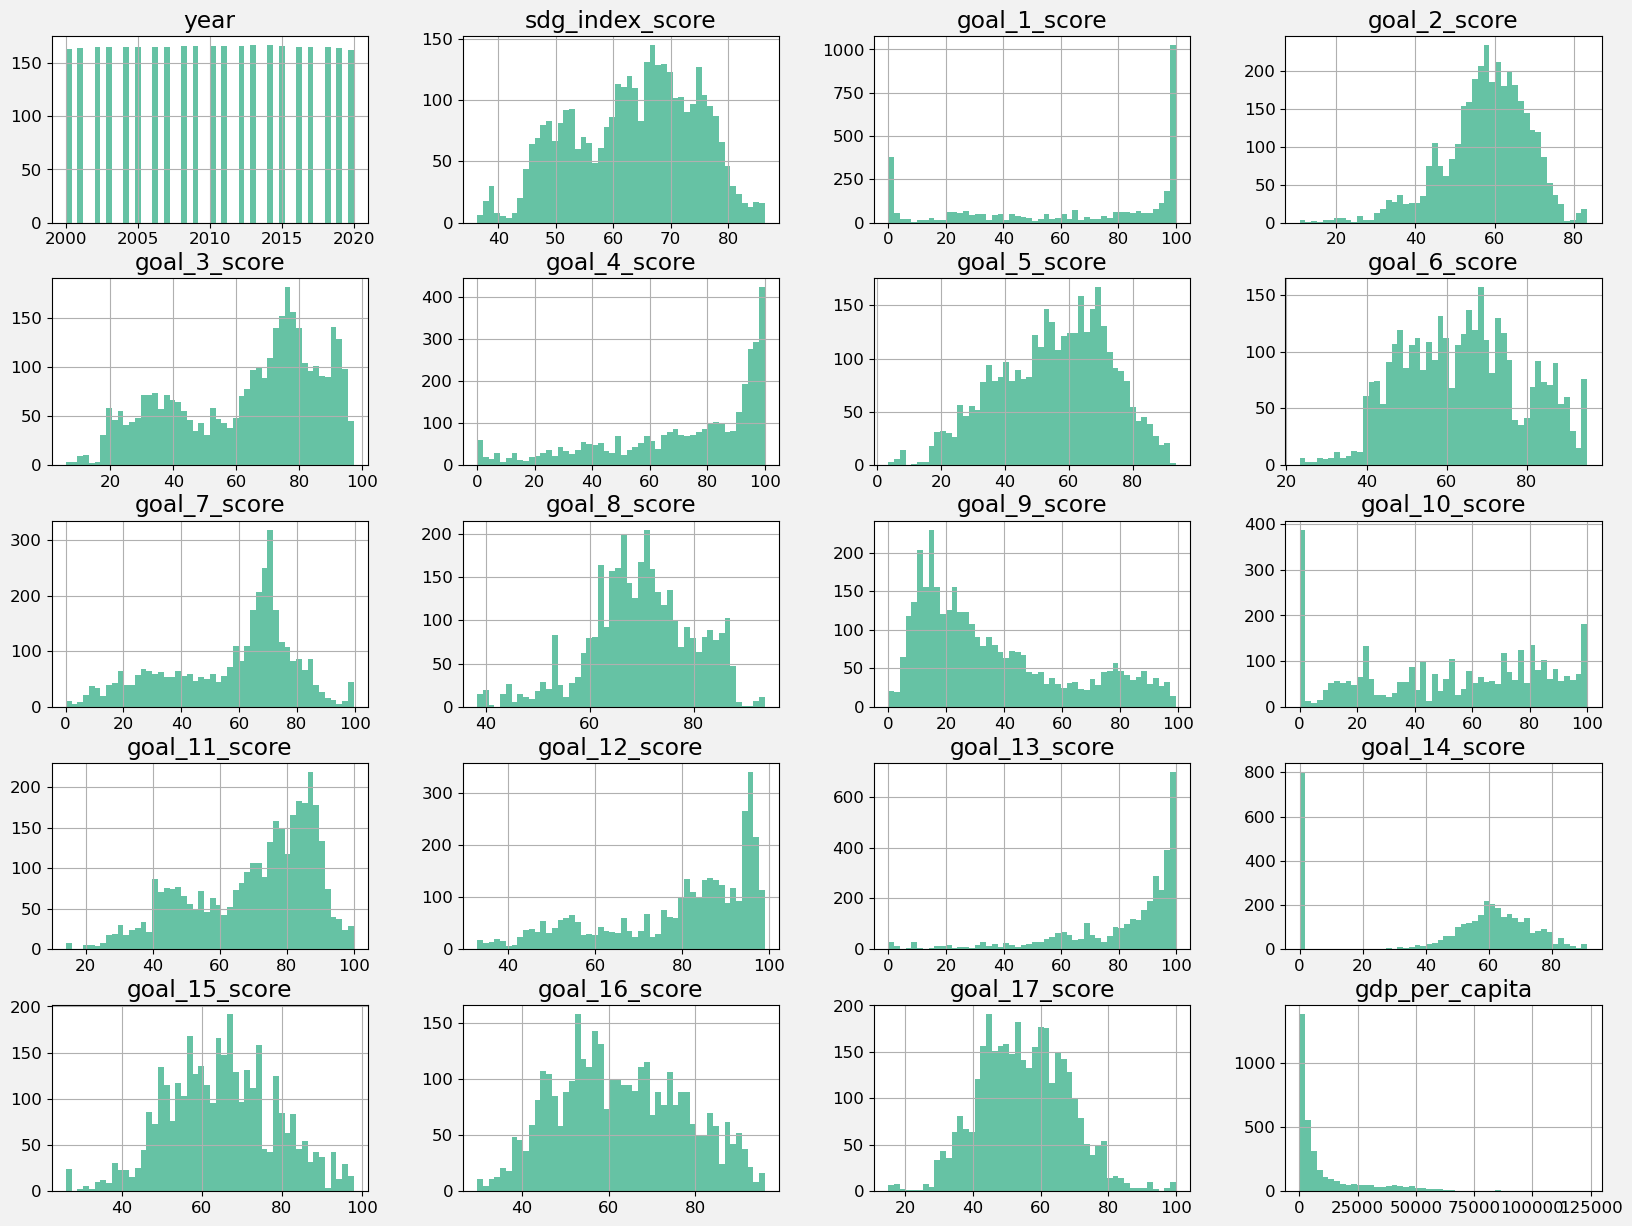

In [102]:
sdg_gdp.hist(figsize = (20,15), bins = 50)
plt.show()

As we observed in the descriptive analysis of the dataset, there are many countries way under the average gdp, this means there are a lot of relative poor countries, who might not have the economy or the sosial structure to score high on the different SDG´s. 

Goal 1, 4, 10 - 14 has a poor gauss distribution. 

Goal 1: No poverty and Goal 4: Education, indicates the huge differences prioritising these goals. Showing the degree of poverty and education follows the same pattern with a lot of countries focusing on it as well as not. 

Goal 10: Redused Inecualities, showes a graph telling us the there are an even gap in priotiticing this goal. 

Goal 11 - 13, are almost exponential so there are a substantial amount prioritising this goal compared to not. 

Goal 14: Life below water, shows the majority not focusing on this goal, yet some have prioritice it at a medium rate. 

The rest of the goals are good enogh to be classified as a gaussian distributed graph, although some are skewed to either side. 

In [119]:
year_counts = sdg_gdp.groupby('year').size().reset_index(name='Count')

print(year_counts)

    year  Count
0   2000    163
1   2001    164
2   2002    165
3   2003    165
4   2004    165
5   2005    165
6   2006    165
7   2007    165
8   2008    166
9   2009    166
10  2010    166
11  2011    166
12  2012    166
13  2013    167
14  2014    167
15  2015    166
16  2016    165
17  2017    165
18  2018    165
19  2019    164
20  2020    162


From the Histogram of year we have notices missing data for some countries. Therefor we create a list of all the countries with missing data and how many years it involves, to see if we have to do something about it. 

In [138]:
countryCount = sdg_gdp.groupby('country').size().reset_index(name = 'count')
countryCount.head()

,country,count
0,Afghanistan,19
1,Albania,21
2,Algeria,21
3,Angola,21
4,Argentina,21


In [213]:
countries = []

for i in range(0, len(countryCount['country'])):
    if countryCount['count'][i] < 21:
        countries.append(countryCount['country'][i])
        countries.append(countryCount['count'][i])
    

In [215]:
c = pd.DataFrame(countries)

In [216]:
c.rename(columns = {0:'Country'}, inplace = True)
c.index = np.arange(1, len(c) + 1)
c

,Country
1,Afghanistan
2,19
3,Sao Tome and Principe
4,20
5,Somalia
6,8
7,South Sudan
8,8
9,Syrian Arab Republic
10,20


Here are the Different countries in the data set who has less years with recorded data than the rest. The standard is 21 years from 2000-2020. But we have concluded that this is too little data to have a real effect on the analysises. So we have not removed them. 

### Correlations

In [132]:
sdg_gdp.corr().style.background_gradient(cmap='coolwarm').format(precision = 1)

C:\Users\MatsN\AppData\Local\Temp\ipykernel_26172\3342140263.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sdg_gdp.corr().style.background_gradient(cmap='coolwarm').format(precision = 1)


,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score,gdp_per_capita
year,1.0,0.2,0.0,0.1,0.2,0.1,0.3,0.1,0.1,0.1,0.3,0.1,0.1,0.0,0.0,0.0,0.1,0.0,0.1,0.1
sdg_index_score,0.2,1.0,0.7,0.7,0.9,0.9,0.7,0.9,0.9,0.7,0.8,0.4,0.8,-0.7,-0.5,0.2,0.2,0.8,0.6,0.6
goal_1_score,0.0,0.7,1.0,0.4,0.6,0.6,0.4,0.7,0.6,0.4,0.5,0.4,0.6,-0.4,-0.2,0.1,0.2,0.5,0.4,0.3
goal_2_score,0.1,0.7,0.4,1.0,0.6,0.6,0.5,0.6,0.5,0.6,0.6,0.2,0.5,-0.4,-0.3,0.1,0.1,0.5,0.2,0.4
goal_3_score,0.2,0.9,0.6,0.6,1.0,0.8,0.6,0.8,0.9,0.7,0.8,0.3,0.8,-0.8,-0.6,0.2,0.0,0.8,0.4,0.6
goal_4_score,0.1,0.9,0.6,0.6,0.8,1.0,0.7,0.7,0.8,0.6,0.7,0.2,0.8,-0.6,-0.5,0.2,0.1,0.6,0.4,0.5
goal_5_score,0.3,0.7,0.4,0.5,0.6,0.7,1.0,0.6,0.6,0.5,0.6,0.1,0.7,-0.5,-0.4,0.0,0.2,0.5,0.5,0.5
goal_6_score,0.1,0.9,0.7,0.6,0.8,0.7,0.6,1.0,0.8,0.7,0.7,0.3,0.7,-0.6,-0.4,0.1,0.2,0.6,0.5,0.5
goal_7_score,0.1,0.9,0.6,0.5,0.9,0.8,0.6,0.8,1.0,0.6,0.7,0.2,0.8,-0.6,-0.5,0.2,0.1,0.7,0.5,0.5
goal_8_score,0.1,0.7,0.4,0.6,0.7,0.6,0.5,0.7,0.6,1.0,0.7,0.3,0.6,-0.6,-0.5,0.2,0.2,0.6,0.3,0.6


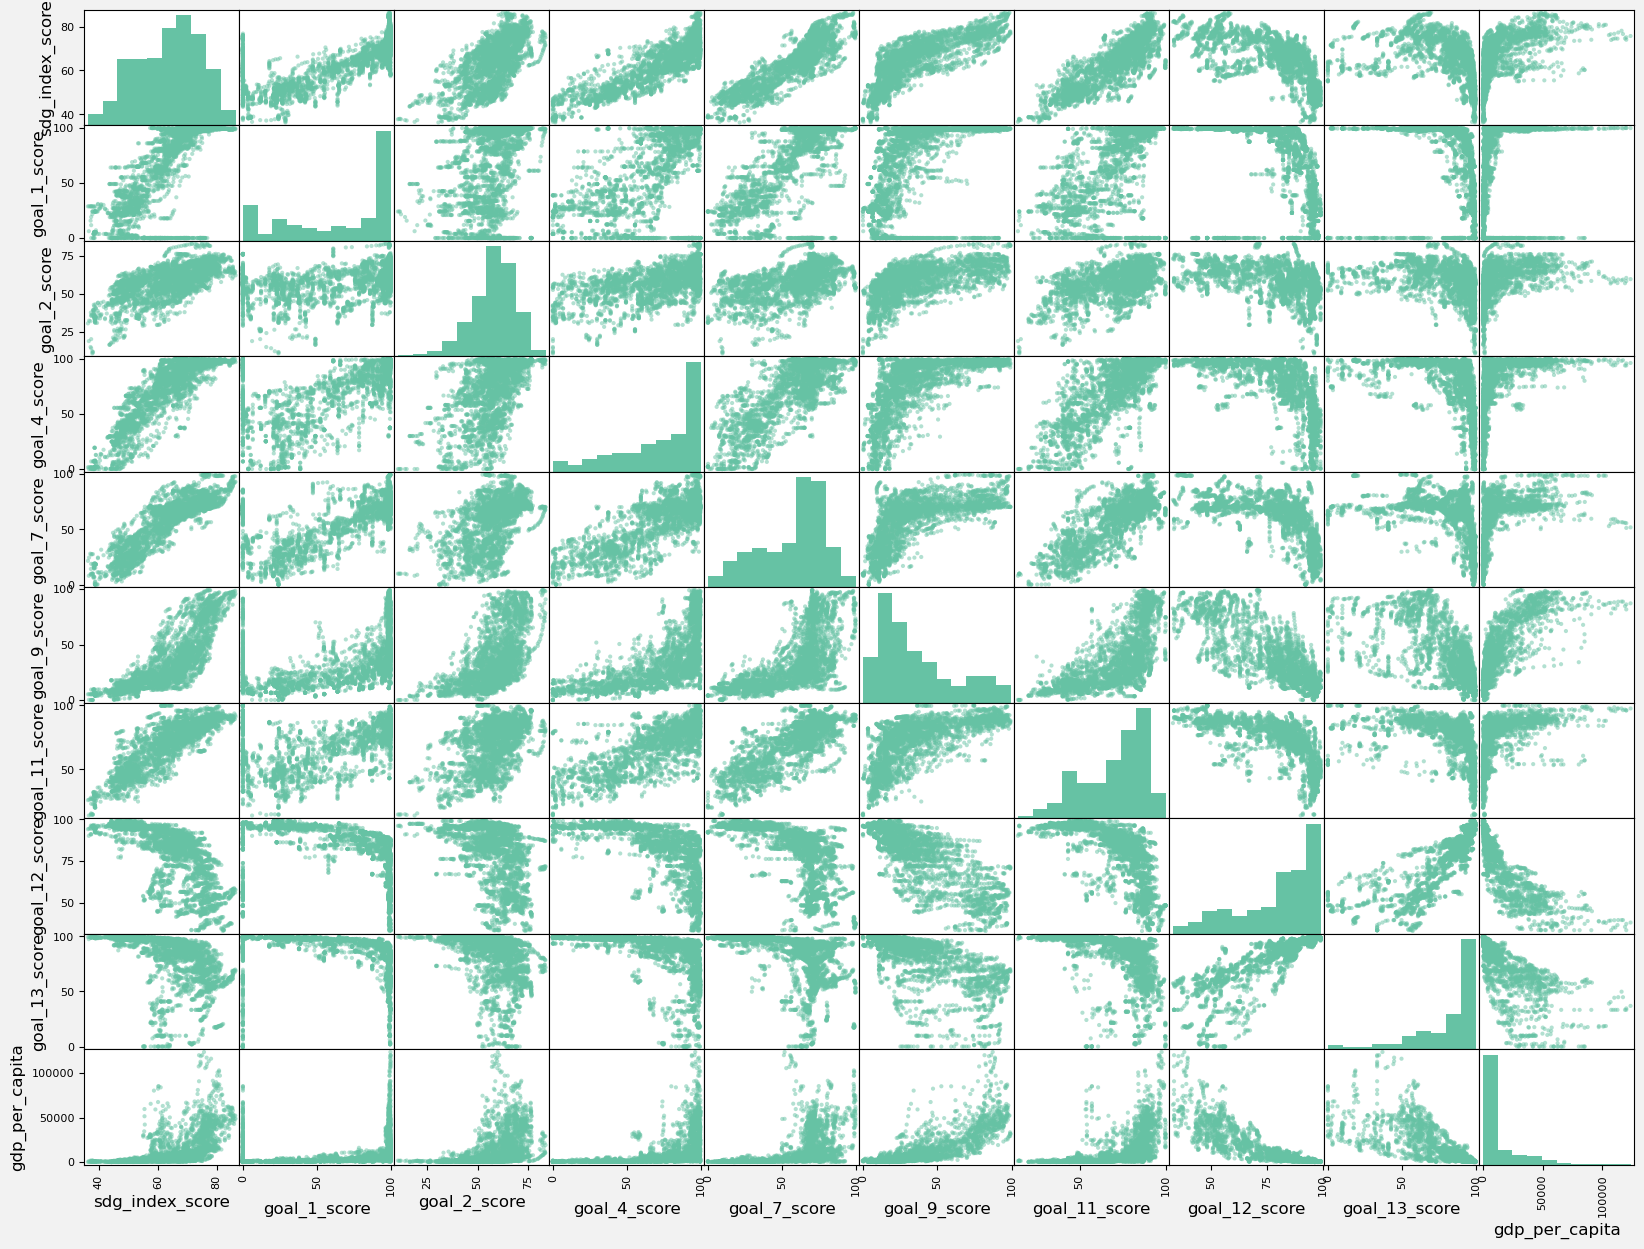

In [133]:
best_corr = ['sdg_index_score',
             'goal_1_score',
             'goal_2_score',
             'goal_4_score', 
             'goal_7_score',
             'goal_9_score',
             'goal_11_score',
             'goal_12_score',
             'goal_13_score',
             'gdp_per_capita']
pd.plotting.scatter_matrix(sdg_gdp[best_corr], figsize=(20,15))
plt.show()

### Regression

Calculating the regression line

In [121]:
slope, intercept = np.polyfit(sdg_gdp["goal_13_score"], sdg_gdp["sdg_index_score"], 1)

Creating a scatter plot, plotting the regression line and labelling the axes

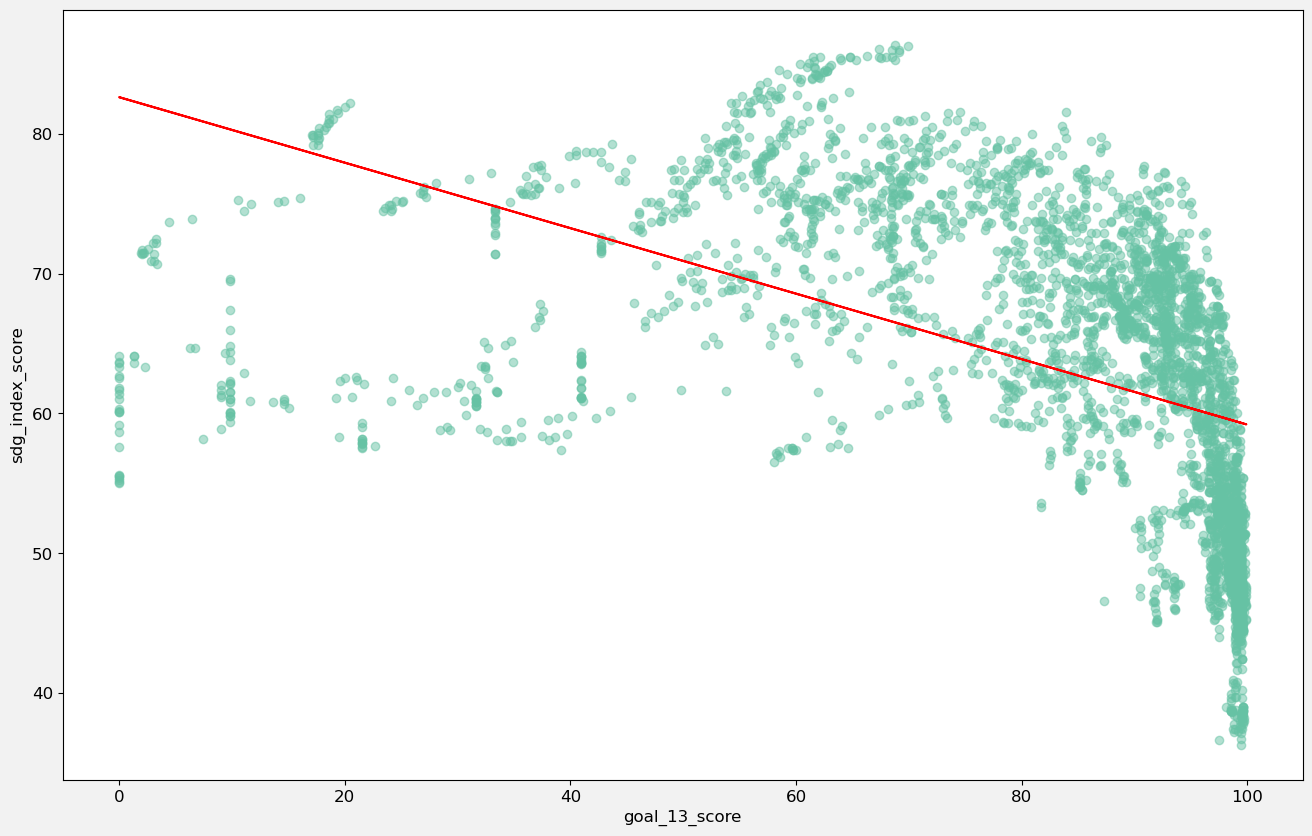

In [122]:
fig, ax = plt.subplots()
ax.scatter(sdg_gdp["goal_13_score"], sdg_gdp["sdg_index_score"], alpha=0.5)

ax.plot(sdg_gdp["goal_13_score"], slope * sdg_gdp["goal_13_score"] + intercept, color='red')

ax.set_xlabel("goal_13_score")
ax.set_ylabel("sdg_index_score")

plt.show()

Here the SDG scores of the countries are compared to the score on goal 13 in a scatter plot. This is from all time and shows a pattern, and a somewhat negative correlation, that is illuminated further by the regression line.

Calculating the regression line

In [123]:
slope, intercept = np.polyfit(sdg_gdp["goal_13_score"], sdg_gdp["gdp_per_capita"], 1)

Creating a scatter plot, plotting the regression line and labelling the axes

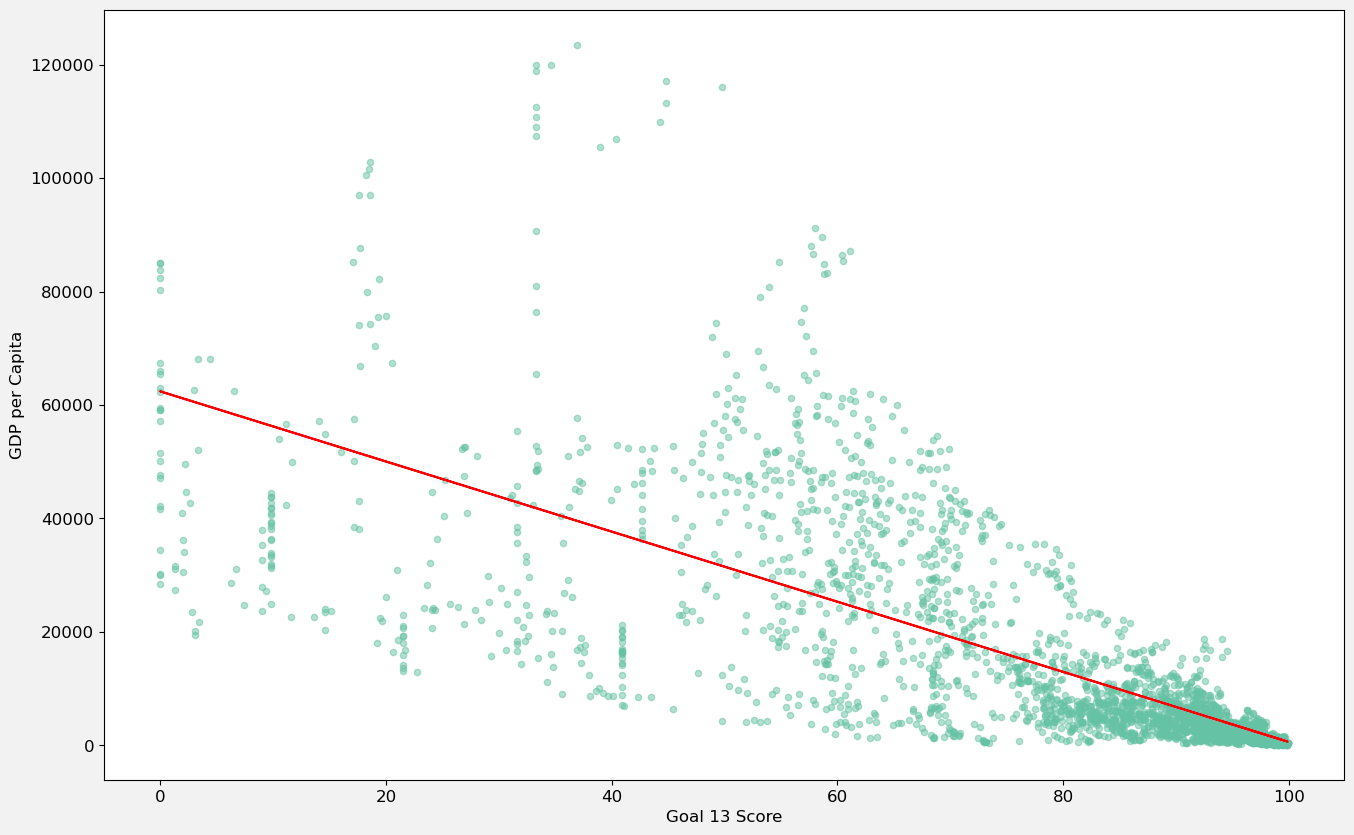

In [124]:
fig, ax = plt.subplots()
sdg_gdp.plot.scatter(x="goal_13_score", y="gdp_per_capita", ax=ax, alpha=0.5)

ax.plot(sdg_gdp["goal_13_score"], slope * sdg_gdp["goal_13_score"] + intercept, color='red')

ax.set_xlabel("Goal 13 Score")
ax.set_ylabel("GDP per Capita")

plt.show()

This graph is a scatter plot of the GDP of all the countries from all time compared to their goal 13 scores. An even more apparent negative correlation is to be found here.

Calculating the regression line

In [125]:
slope, intercept = np.polyfit(sdg_gdp["sdg_index_score"], sdg_gdp["gdp_per_capita"], 1)

Creating the scatterplot, plotting the regression line and labelling the axes

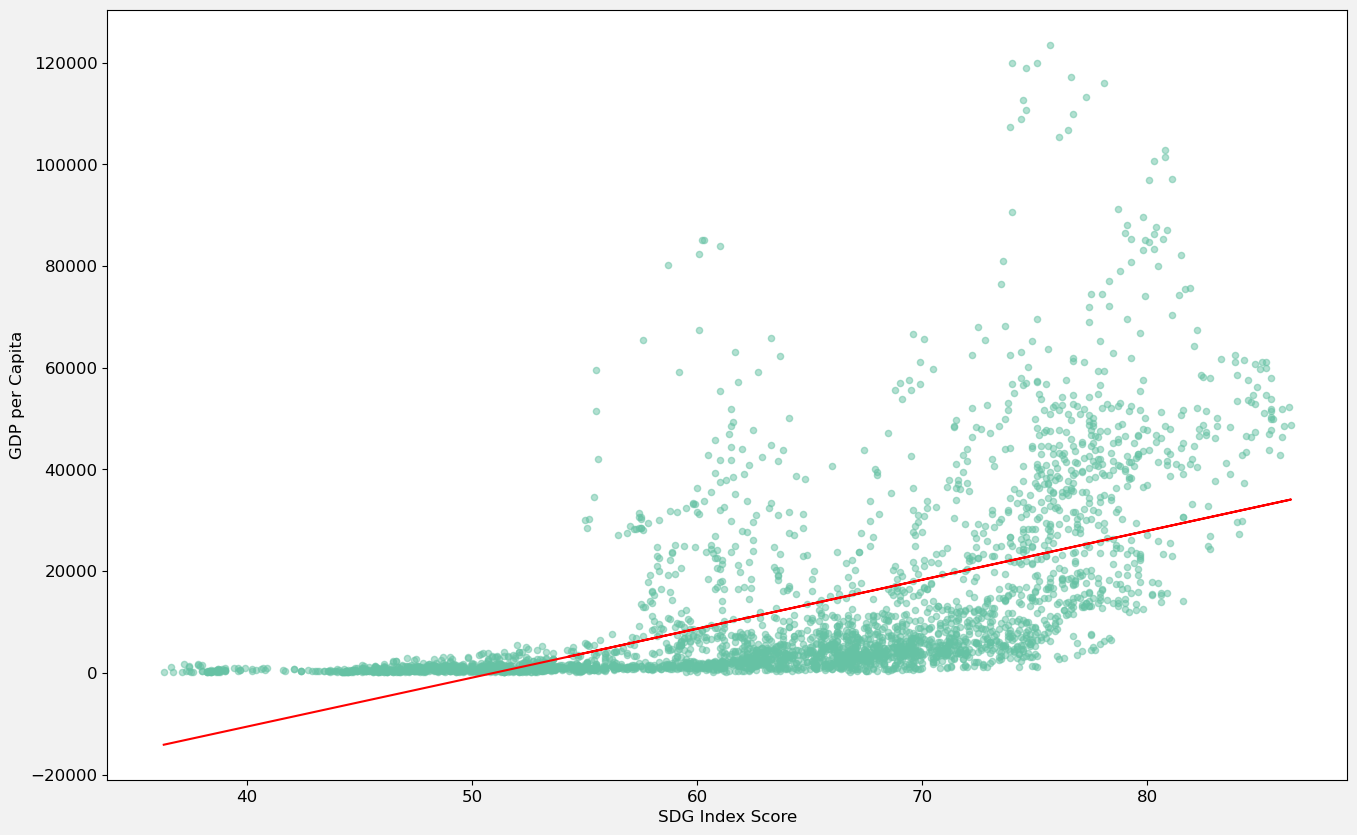

In [126]:
fig, ax = plt.subplots()
sdg_gdp.plot.scatter(x="sdg_index_score", y="gdp_per_capita", ax=ax, alpha=0.5)

ax.plot(sdg_gdp["sdg_index_score"], slope * sdg_gdp["sdg_index_score"] + intercept, color='red')

ax.set_xlabel("SDG Index Score")
ax.set_ylabel("GDP per Capita")

plt.show()

When comparing the GDP to the SDG score, the correlation seems to be positive. This is also data from all time.

Creating the facets, plotting the scatterplots in the facets, creating regression lines and then plotting them for every facet and labelling the facets

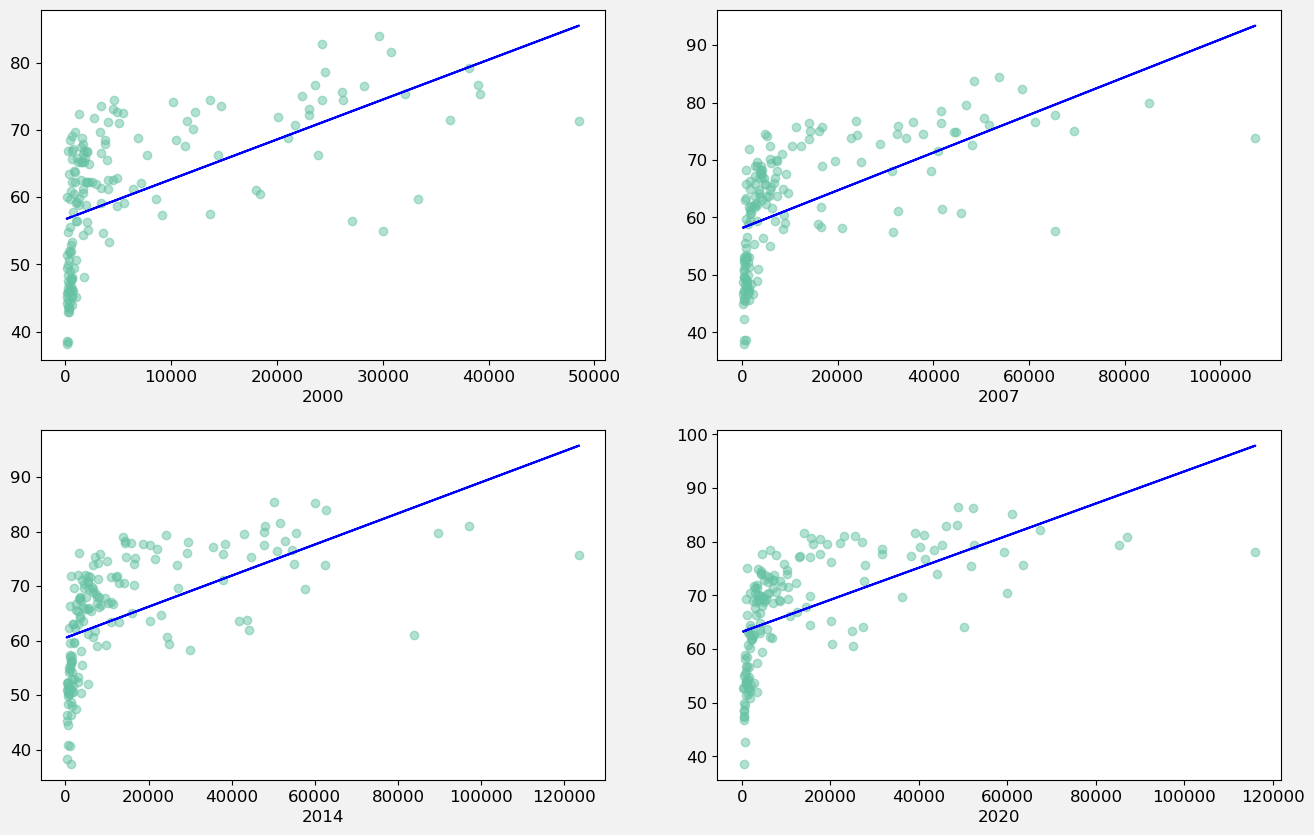

In [127]:
fig, ax = plt.subplots(2, 2)

ax[0,0].scatter(x=sdg_gdp.loc[sdg_gdp.year==2000].gdp_per_capita, y=sdg_gdp.loc[sdg_gdp.year==2000].sdg_index_score,  alpha=.5)
ax[0,1].scatter(x=sdg_gdp.loc[sdg_gdp.year==2007].gdp_per_capita, y=sdg_gdp.loc[sdg_gdp.year==2007].sdg_index_score,  alpha=.5)
ax[1,0].scatter(x=sdg_gdp.loc[sdg_gdp.year==2014].gdp_per_capita, y=sdg_gdp.loc[sdg_gdp.year==2014].sdg_index_score, alpha=.5)
ax[1,1].scatter(x=sdg_gdp.loc[sdg_gdp.year==2020].gdp_per_capita, y=sdg_gdp.loc[sdg_gdp.year==2020].sdg_index_score, alpha=.5)


slope, intercept, r_value, p_value, std_err = spt.linregress(sdg_gdp.loc[sdg_gdp.year==2000,"gdp_per_capita"], sdg_gdp.loc[sdg_gdp.year==2000, "sdg_index_score"]) #Making a regression line for the blue plots (1990)
line_2000 = slope * sdg_gdp.loc[sdg_gdp.year==2000,"gdp_per_capita"] + intercept

ax[0,0].plot(sdg_gdp.loc[sdg_gdp.year==2000,"gdp_per_capita"], line_2000, linestyle='-', color='blue')

slope, intercept, r_value, p_value, std_err = spt.linregress(sdg_gdp.loc[sdg_gdp.year==2007,"gdp_per_capita"], sdg_gdp.loc[sdg_gdp.year==2007, "sdg_index_score"]) #Making a regression line for the blue plots (1990)
line_2007 = slope * sdg_gdp.loc[sdg_gdp.year==2007,"gdp_per_capita"] + intercept

ax[0,1].plot(sdg_gdp.loc[sdg_gdp.year==2007,"gdp_per_capita"], line_2007, linestyle='-', color='blue')

slope, intercept, r_value, p_value, std_err = spt.linregress(sdg_gdp.loc[sdg_gdp.year==2014,"gdp_per_capita"], sdg_gdp.loc[sdg_gdp.year==2014, "sdg_index_score"]) #Making a regression line for the blue plots (1990)
line_2014 = slope * sdg_gdp.loc[sdg_gdp.year==2014,"gdp_per_capita"] + intercept

ax[1,0].plot(sdg_gdp.loc[sdg_gdp.year==2014,"gdp_per_capita"], line_2014, linestyle='-', color='blue')

slope, intercept, r_value, p_value, std_err = spt.linregress(sdg_gdp.loc[sdg_gdp.year==2020,"gdp_per_capita"], sdg_gdp.loc[sdg_gdp.year==2020, "sdg_index_score"]) #Making a regression line for the blue plots (1990)
line_2020 = slope * sdg_gdp.loc[sdg_gdp.year==2020,"gdp_per_capita"] + intercept

ax[1,1].plot(sdg_gdp.loc[sdg_gdp.year==2020,"gdp_per_capita"], line_2020, linestyle='-', color='blue')


ax[0,0].set_xlabel("2000")

ax[0,1].set_xlabel("2007")

ax[1,0].set_xlabel("2014")

ax[1,1].set_xlabel("2020")

plt.show()

These four graphs show the GDP’s correlation with the SDG score for each country the years 2000, 2007, 2014 and 2020. In addition to showing a correlation that is apparent to the naked eye, they also show a development where the SDG score of all the countries seem to rise somewhat. The regression line makes it easier to spot as well as showing the direction of the correlation. Furthermore, this apparent rise in SDG score is supported by the following boxplot graph.

Limiting the data to only the relevant for the upcoming boxplot and setting the year column as the index

In [128]:
boxplot=sdg_gdp.loc[:,['year','sdg_index_score']]
boxplot.set_index('year', inplace=True)

Dividing every year into its own dataframe to make it easier to plot later on, then dropping the index as it is the same in every column and then renaming the column name to the relevant name

In [129]:
b2000=boxplot.loc[boxplot.index==2000]
b2001=boxplot.loc[boxplot.index==2001]
b2002=boxplot.loc[boxplot.index==2002]
b2003=boxplot.loc[boxplot.index==2003]
b2004=boxplot.loc[boxplot.index==2004]
b2005=boxplot.loc[boxplot.index==2005]
b2006=boxplot.loc[boxplot.index==2006]
b2007=boxplot.loc[boxplot.index==2007]
b2008=boxplot.loc[boxplot.index==2008]
b2009=boxplot.loc[boxplot.index==2009]
b2010=boxplot.loc[boxplot.index==2010]
b2011=boxplot.loc[boxplot.index==2011]
b2012=boxplot.loc[boxplot.index==2012]
b2013=boxplot.loc[boxplot.index==2013]
b2014=boxplot.loc[boxplot.index==2014]
b2015=boxplot.loc[boxplot.index==2015]
b2016=boxplot.loc[boxplot.index==2016]
b2017=boxplot.loc[boxplot.index==2017]
b2018=boxplot.loc[boxplot.index==2018]
b2019=boxplot.loc[boxplot.index==2019]
b2020=boxplot.loc[boxplot.index==2020]

b2000=b2000.reset_index(drop=True).rename(columns={'sdg_index_score': 2000})
b2001=b2001.reset_index(drop=True).rename(columns={'sdg_index_score': 2001})
b2002=b2002.reset_index(drop=True).rename(columns={'sdg_index_score': 2002})
b2003=b2003.reset_index(drop=True).rename(columns={'sdg_index_score': 2003})
b2004=b2004.reset_index(drop=True).rename(columns={'sdg_index_score': 2004})
b2005=b2005.reset_index(drop=True).rename(columns={'sdg_index_score': 2005})
b2006=b2006.reset_index(drop=True).rename(columns={'sdg_index_score': 2006})
b2007=b2007.reset_index(drop=True).rename(columns={'sdg_index_score': 2007})
b2008=b2008.reset_index(drop=True).rename(columns={'sdg_index_score': 2008})
b2009=b2009.reset_index(drop=True).rename(columns={'sdg_index_score': 2009})
b2010=b2010.reset_index(drop=True).rename(columns={'sdg_index_score': 2010})
b2011=b2011.reset_index(drop=True).rename(columns={'sdg_index_score': 2011})
b2012=b2012.reset_index(drop=True).rename(columns={'sdg_index_score': 2012})
b2013=b2013.reset_index(drop=True).rename(columns={'sdg_index_score': 2013})
b2014=b2014.reset_index(drop=True).rename(columns={'sdg_index_score': 2014})
b2015=b2015.reset_index(drop=True).rename(columns={'sdg_index_score': 2015})
b2016=b2016.reset_index(drop=True).rename(columns={'sdg_index_score': 2016})
b2017=b2017.reset_index(drop=True).rename(columns={'sdg_index_score': 2017})
b2018=b2018.reset_index(drop=True).rename(columns={'sdg_index_score': 2018})
b2019=b2019.reset_index(drop=True).rename(columns={'sdg_index_score': 2019})
b2020=b2020.reset_index(drop=True).rename(columns={'sdg_index_score': 2020})

Concating all the years together

In [130]:
samling=pd.concat([b2000,b2001,b2002,b2003,b2004,b2005,b2006,b2007,b2008,b2009,b2010,b2011,b2012,b2013,b2014,b2015,b2016,b2017,b2018,b2019,b2020],axis=1)

Plotting and labelling the boxplot

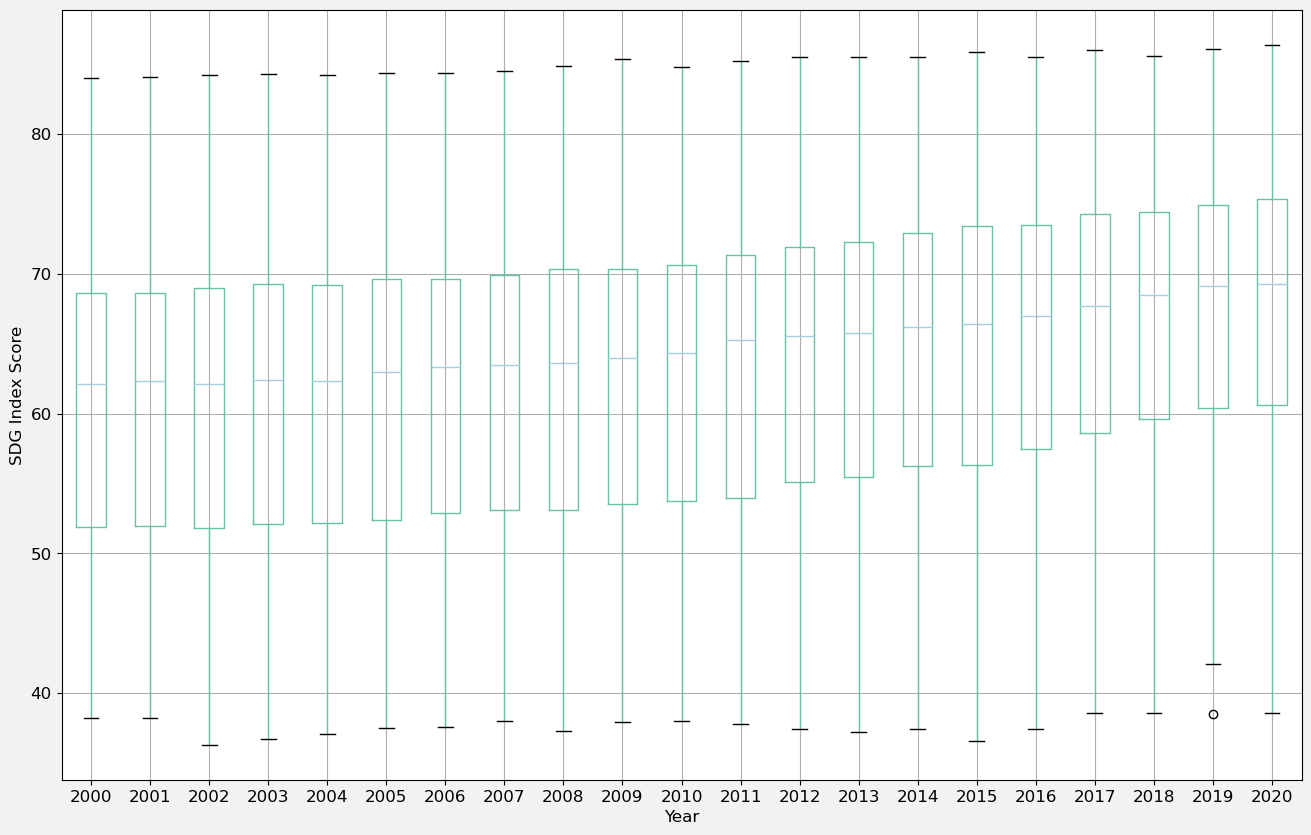

In [131]:
fig, ax = plt.subplots()
samling.boxplot()

plt.ylabel('SDG Index Score')
plt.xlabel('Year')

plt.show()

Here one can plainly see that the mean rises. It is not only the mean that rises, but also the whole body of the normal distribution that is moved upwards. There is one outlier in 2019, however, this seems to be more of a problem with the algorithm as the outlier lays where the bottom of the distribution is the previous and following year. The interquartile range also becomes smaller from 2000 to 2020.

<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Analysis

    
</p>

### Basic Statistics

In [14]:
sdg_gdp.describe()

,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score,gdp_per_capita
count,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000
mean,2010.002595,63.559948,64.542272,57.843022,63.883795,71.751009,55.507439,64.327278,57.254296,69.752364,35.824625,52.102393,70.142734,79.206084,81.357180,48.226471,64.843080,62.713293,55.166119,12119.960761
std,6.039792,10.747048,36.621784,10.732964,22.624269,27.121249,17.333896,15.075151,21.849523,10.079501,25.657423,31.908817,18.157585,17.127075,22.000835,28.173190,13.581288,14.614935,13.121977,18061.714737
min,2000.000000,36.300000,0.000000,10.800000,5.900000,0.000000,3.500000,23.300000,0.100000,38.400000,0.000000,0.000000,14.100000,32.900000,0.000000,0.000000,26.000000,29.600000,15.100000,111.927225
25%,2005.000000,54.800000,30.800000,52.300000,43.875000,55.375000,42.700000,52.400000,40.600000,63.900000,15.200000,23.100000,56.300000,67.500000,71.200000,40.800000,55.200000,51.800000,45.400000,1201.447820
50%,2010.000000,65.000000,81.050000,58.800000,70.550000,80.700000,57.200000,64.400000,64.800000,70.000000,27.500000,55.050000,75.200000,84.700000,90.700000,58.800000,64.800000,61.600000,54.700000,4068.578455
75%,2015.000000,71.900000,98.600000,65.200000,81.300000,94.900000,68.600000,74.500000,71.900000,76.500000,50.125000,80.400000,85.000000,94.200000,97.200000,67.500000,74.100000,74.000000,64.500000,14615.705531
max,2020.000000,86.400000,100.000000,83.400000,97.300000,100.000000,93.600000,95.100000,99.600000,93.600000,99.200000,100.000000,99.900000,99.000000,99.900000,91.200000,97.900000,96.000000,100.000000,123514.196686


There are more countries with a sdg score under the mean than over. This is because the 50% sdg_index_score is 65 and the mean sdg_index_score is 65.56. Some countries have a much higher GDP than the average score. The mean equals 12120 and the 50% score equals 4069. The 75% score equals 14615. This means that almost 75% of the countries in our dataframe has a GDP lower than the average. 

We also see that some of the goal scores equals to 0. In the dataset some 0-values are real, but some are missing values. 

### Ordinary Least Squares - Linear Regression

**What is OLS - Ordinary least squares**

OLS is a method used to fit a linear regression line to your data. The way the OLS regression line is calculated is by minimizing the deviation between observed value and predicted value. The numbers are also squared to take negative values into account, so that positive and negative values do not cancel each other out. The OLS model gives a good overview of whether the model is good or bad given the data we use as input. 

In this part of our assignment we seek to find a model to predict GDP per capita based on the SDG index. We make three different models using the .ols function, to find out which one is the best. The first model (mod1) includes all of the variables in our dataframe, except sdg_index_score. This is because sdg_index_score is the average of all the goals and will therefore not make the model better. The second model (mod2) is sdg_index_score on gdp_per_capita. The third model (mod3) includes all statistically relevant variables.

In [54]:
goal_score = """goal_1_score + goal_2_score + goal_3_score + goal_4_score + goal_5_score + goal_6_score + 
goal_7_score + goal_8_score + goal_9_score + goal_10_score + goal_11_score + goal_12_score + goal_13_score + 
goal_14_score + goal_15_score + goal_16_score + goal_17_score""" 
mod1 = smf.ols(formula = f'gdp_per_capita ~ {goal_score}+ year', data=sdg_gdp).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         gdp_per_capita   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     757.1
Date:                Wed, 25 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:21:34   Log-Likelihood:                -36138.
No. Observations:                3468   AIC:                         7.231e+04
Df Residuals:                    3449   BIC:                         7.243e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -1.768e+05    5.9e+04     -2.997      0.003   -2.92e+05   -6.11e+04
goal_1_score    -26.9863      5.860     -4.605      0.000     -38.475     -15.497
goal_2_score    -30.6962     18.864     -1.627      0.104     -67.683       6.290
goal_3_score    -23.2209     20.013     -1.160      0.246     -62.459      16.017
goal_4_score    -81.3480     11.091     -7.335      0.000    -103.093     -59.603
goal_5_score     58.5677     13.715      4.270      0.000      31.678      85.458
goal_6_score     -6.0063     19.233     -0.312      0.755     -43.716      31.703
goal_7_score    -54.6468     13.992     -3.906      0.000     -82.080     -27.214
goal_8_score     29.2784     22.042      1.328      0.184     -13.939      72.496
goal_9_score    307.4768     13.777     22.319      0.000     280.466     334.488
goal_10_score    12.9278      5.498      2.351      0.019       2.149      23.707
goal_11_score   -62.1811     16.045     -3.875      0.000     -93.640     -30.722
goal_12_score  -503.4180     24.197    -20.805      0.000    -550.860    -455.975
goal_13_score  -134.2220     12.356    -10.863      0.000    -158.448    -109.996
goal_14_score   -17.0774      5.253     -3.251      0.001     -27.377      -6.777
goal_15_score   -34.3318     11.641     -2.949      0.003     -57.157     -11.507
goal_16_score    87.8897     18.010      4.880      0.000      52.578     123.201
goal_17_score    -5.3437     13.420     -0.398      0.691     -31.656      20.968
year            119.0387     29.626      4.018      0.000      60.952     177.125
==============================================================================
Omnibus:                     2029.666   Durbin-Watson:                   0.171
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            41405.902
Skew:                           2.378   Prob(JB):                         0.00
Kurtosis:                      19.246   Cond. No.                     8.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [55]:
mod2 = smf.ols(formula = 'gdp_per_capita ~ sdg_index_score', data=sdg_gdp).fit()
mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         gdp_per_capita   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     1691.
Date:                Wed, 25 Oct 2023   Prob (F-statistic):          2.04e-301
Time:                        13:21:37   Log-Likelihood:                -38223.
No. Observations:                3468   AIC:                         7.645e+04
Df Residuals:                    3466   BIC:                         7.646e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -4.905e+04   1508.597    -32.513      0.000    -5.2e+04   -4.61e+04
sdg_index_score   962.3763     23.403     41.122      0.000     916.491    1008.261
==============================================================================
Omnibus:                     1692.726   Durbin-Watson:                   0.098
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12107.853
Skew:                           2.218   Prob(JB):                         0.00
Kurtosis:                      11.007   Cond. No.                         387.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [56]:
goal_score3 = """goal_1_score + goal_2_score  + goal_4_score + goal_5_score + goal_7_score + goal_9_score + 
goal_10_score + goal_11_score + goal_12_score + goal_13_score + goal_14_score + goal_15_score + goal_16_score""" 
mod3 = smf.ols(formula = f'gdp_per_capita ~ {goal_score3} + year', data=sdg_gdp).fit()
mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         gdp_per_capita   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     973.4
Date:                Wed, 25 Oct 2023   Prob (F-statistic):               0.00
Time:                        13:21:39   Log-Likelihood:                -36140.
No. Observations:                3468   AIC:                         7.231e+04
Df Residuals:                    3453   BIC:                         7.240e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -1.523e+05   5.49e+04     -2.775      0.006    -2.6e+05   -4.47e+04
goal_1_score    -29.4920      5.553     -5.311      0.000     -40.379     -18.605
goal_2_score    -27.6868     17.730     -1.562      0.118     -62.449       7.075
goal_4_score    -84.3864     10.442     -8.082      0.000    -104.859     -63.914
goal_5_score     61.2091     12.931      4.733      0.000      35.855      86.563
goal_7_score    -62.5335     12.658     -4.940      0.000     -87.351     -37.716
goal_9_score    308.1081     13.058     23.596      0.000     282.506     333.710
goal_10_score    13.9218      5.443      2.558      0.011       3.250      24.594
goal_11_score   -67.0399     15.584     -4.302      0.000     -97.595     -36.484
goal_12_score  -500.8372     23.326    -21.471      0.000    -546.572    -455.103
goal_13_score  -134.8866     12.297    -10.969      0.000    -158.996    -110.777
goal_14_score   -16.9687      5.212     -3.256      0.001     -27.187      -6.751
goal_15_score   -31.8383     11.114     -2.865      0.004     -53.629     -10.048
goal_16_score    81.8494     17.238      4.748      0.000      48.051     115.647
year            107.2238     27.608      3.884      0.000      53.095     161.353
==============================================================================
Omnibus:                     2032.930   Durbin-Watson:                   0.171
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            41519.799
Skew:                           2.383   Prob(JB):                         0.00
Kurtosis:                      19.267   Cond. No.                     8.03e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.03e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [57]:
r_squared1 = mod1.rsquared_adj
r_squared2 = mod2.rsquared_adj
r_squared3 = mod3.rsquared_adj
print('Adjusted R^2 for model 1 is:', r_squared1)
print('Adjusted R^2 for model 2 is:', r_squared2)
print('Adjusted R^2 for model 3 is:', r_squared3)

Adjusted R^2 for model 1 is: 0.7969758803217917
Adjusted R^2 for model 2 is: 0.3277127634413375
Adjusted R^2 for model 3 is: 0.7970283341435968


Model 3 has the highest score for adjusted $R^2$, although just higher than model 1. The adjusted $R^2$ measures how much the independent variables in the model explains the variability in the dependen variable. In model 3 we excluded every independent variable that was not statistically significant. If we assume a 95% certainty the P>|t| needs to be below 0.005 to reject the null hypothesis about a non existent relationship between the dependent and the independent variable. The t distribution  with a great amount of observations is approximately normally distributed, and therefore the critical value is +-1.96, given a 95% confidence level. As we can see from model 3, every independent variable has a p-value lower than 0.005 and a t-value higher or lower than 1.96. We can say that our independent variables have a significant relationship with the dependent variable. 

Under we will predict the GDP numbers for 2021 and 2022 by using the SDG dataset only including data from 2021 and 2022. 

In [58]:
# Making the dataset that only contains data from 2021 and 2022
sdg2122 = sdg.loc[(sdg.year == 2021) | (sdg.year == 2022)].copy()
sdg2122 = sdg2122.reset_index(drop=True)
sdg2122

,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
0,Afghanistan,2021,46.3,20.0,46.7,37.5,34.4,32.9,50.4,35.9,39.5,9.7,0.0,29.4,96.7,99.0,0.0,73.2,44.6,45.3
1,Afghanistan,2022,49.0,12.4,46.9,37.5,34.4,32.9,50.4,35.9,39.5,9.7,0.0,24.5,96.7,99.0,0.0,73.2,44.8,45.3
2,Albania,2021,73.7,98.5,59.1,82.1,86.8,60.7,73.7,84.3,66.1,43.6,88.1,77.4,81.7,90.6,50.2,79.8,63.6,66.1
3,Albania,2022,73.5,98.6,59.3,81.9,86.8,60.8,73.7,84.3,66.2,43.6,88.1,77.4,81.7,90.6,50.2,79.6,60.7,66.1
4,Algeria,2021,71.0,97.3,57.5,76.8,69.3,40.9,58.0,65.5,67.4,53.2,97.0,64.7,89.2,88.6,64.8,67.1,67.7,81.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,"Yemen, Rep.",2022,46.8,4.6,28.8,44.5,41.8,13.1,36.2,36.9,53.2,14.2,66.3,53.0,96.0,98.7,74.9,48.4,35.9,50.1
330,Zambia,2021,53.2,9.7,59.4,44.9,66.7,65.1,52.9,44.7,65.1,20.2,8.3,54.5,94.9,98.0,0.0,68.4,43.9,55.2
331,Zambia,2022,54.3,9.9,59.5,45.6,66.7,65.1,52.9,44.7,65.1,20.2,8.3,58.1,94.9,98.0,0.0,68.4,44.1,54.9
332,Zimbabwe,2021,54.8,20.8,48.4,41.9,62.5,77.1,51.1,41.6,63.1,27.0,24.0,61.2,94.5,94.3,0.0,77.9,43.1,48.1


We make a function that outputs a prediction of every country's GDP per person.

In [59]:
# Use the fitted model to make predictions on new data
predic1 = mod1.predict(sdg2122)
predic2 = mod2.predict(sdg2122)
predic3 = mod3.predict(sdg2122)

def prediction_model(prediction):
    predicdf = pd.DataFrame(prediction)
    predicdf['country'], predicdf['year'] = sdg2122['country'], sdg2122['year']
    predicdf = predicdf.rename(columns={0:'Estimated GDPpp'})
    return predicdf[['country', 'year', 'Estimated GDPpp']]

In [60]:
prediction_model(predic1)

,country,year,Estimated GDPpp
0,Afghanistan,2021,-685.211135
1,Afghanistan,2022,-44.950184
2,Albania,2021,8870.908454
3,Albania,2022,8746.524199
4,Algeria,2021,11314.298950
...,...,...,...
329,"Yemen, Rep.",2022,-1145.534423
330,Zambia,2021,1408.834665
331,Zambia,2022,1298.480844
332,Zimbabwe,2021,4899.401077


In [61]:
prediction_model(predic2)

,country,year,Estimated GDPpp
0,Afghanistan,2021,-4490.604337
1,Afghanistan,2022,-1892.188309
2,Albania,2021,21878.506458
3,Albania,2022,21686.031197
4,Algeria,2021,19280.090431
...,...,...,...
329,"Yemen, Rep.",2022,-4009.416184
330,Zambia,2021,2149.792177
331,Zambia,2022,3208.406114
332,Zimbabwe,2021,3689.594268


In [62]:
prediction_model(predic3)

,country,year,Estimated GDPpp
0,Afghanistan,2021,-90.063738
1,Afghanistan,2022,580.627213
2,Albania,2021,9096.891422
3,Albania,2022,8970.754136
4,Algeria,2021,11555.859656
...,...,...,...
329,"Yemen, Rep.",2022,-1007.042467
330,Zambia,2021,1356.948492
331,Zambia,2022,1230.531569
332,Zimbabwe,2021,4812.940946


To get a sense of which model represents the real GDP per person the best we will look at the estimated GDP per person from each model in a selection of three countries. We will look at Albania, Austria, and The United Arab Emirates.

In [63]:
# Limiting the dataframe to the countries we are focusing on.
pred1 = prediction_model(predic1)
pred2 = prediction_model(predic2)
pred3 = prediction_model(predic3)
pred1 = pred1.loc[(pred1.country == 'Albania') | (pred1.country == 'Austria') | (pred1.country == 'United Arab Emirates')]
pred2 = pred2.loc[(pred2.country == 'Albania') | (pred2.country == 'Austria') | (pred2.country == 'United Arab Emirates')]
pred3 = pred3.loc[(pred3.country == 'Albania') | (pred3.country == 'Austria') | (pred3.country == 'United Arab Emirates')]

# Displaying every model in the same dataframe.
modelsOverview = pred1
modelsOverview['Model 2'] = pred2['Estimated GDPpp']
modelsOverview['Model 3'] = pred3['Estimated GDPpp']
modelsOverview = modelsOverview.rename(columns={'Estimated GDPpp': 'Model 1'})
modelsOverview

,country,year,Model 1,Model 2,Model 3
2,Albania,2021,8870.908454,21878.506458,9096.891422
3,Albania,2022,8746.524199,21686.031197,8970.754136
14,Austria,2021,48302.413002,30924.843738,48209.104602
15,Austria,2022,48460.900122,30154.942693,48344.835143
312,United Arab Emirates,2021,49649.908159,18221.476494,49798.699846
313,United Arab Emirates,2022,49855.972244,18029.001233,49999.623760


The first thing we noticed is that for some of the countries for some of the years the GDP per person is negative, this is indicative of the model not being completely accurate, because of course the GDP cannot be negative. However, as we saw when we measured the adjusted $R^2$, the third model (the result displayed direcly above) is the strongest one. To show this we will compare the predicted values against the acutal values recorded in 2021 and 2022.

According to The International Monetary Fund the GDP per person in Albania in 2021 was 6,260 and in 2022 the number was 6,600. In our prediction model number 3 we got approximately 3,000 more in GDP. In other words not very precise. The real numbers for Austria are 53,530 for 2021 and 52,190 for 2022 which is approximately 4,000 lower than our prediction. The real GDP per capita in the United Arab Emirates for 2021 and 2022 are 43,440 and 51,400. In comparison the predicted values are 49,799 and 49,999, which are a quite good prediction, especially for 2022.  

To compare, if we look at the numbers from model 1 we get 8,870 and 8,746 in Albania for respectively 2021 and 2022. And model 2 gives 21,878 for 2021 and 21,686 for 2022. In Austria model 1 gives us 48,302 and 48,460, and model 2 gives us 30,924 and 30,154. And finally, if we look at The United Arab Emirates we see that model 1 predicts a GDP per person of 49,649 in 2021 and 49,855 in 2022, and model 2 predicts 18,221 and 18,029.

By looking at the numbers we can clearly see how model 2 is much less accurate than the other two models, this agrees with the $R^2$ values we looked at earlier in this section, where we observed a $R^2$ of .327 for model 2 and .796 and .797 for model 1 and 3 respectively. This reflects the bad predictions we get from model 2, which to remind you is based on the overall (average) SDG score. 

Looking at model 1 against model 3 however shows a minuscule difference in predictions. These selections actually show that model 1 has better predictions closer to the actual GDP per person, model 1 gets closer for all countries for all years except in The United Arab Emirates in 2022 where model 3 has a (slightly) better prediction. The deviation from our previous assumptions is not very surprising, the $R^2$ values are very similar and therefore the models (1 and 3) should be expected to produce approximately the same predictions. 

We should also address that the selection of countries we have looked at in this comparison is very isolated and does not necessarily represent every prediction made from each model. The selection does however illustrate how each model is different (and not different) from each other, and it shows that the accuracy based on $R^2$ can be trusted to judge which model is better.

Source: International Monetary Fund. GDP per capita, current prices. Retrived from (10.20.2023): https://www.imf.org/external/datamapper/NGDPDPC@WEO/OEMDC/ADVEC/WEOWORLD

### Machine learning

Machine learning in python: 
Machine learning in python is a process where we use different libraries in python to manipulate and process data to eventually make predictions on how the data will continue to evolve. Some of the most popular libraries, and those we use in this model are numpy, pandas, matplotlib, and sklearn. Pandas and numpy are libraries mainly used for structuring and manipulation of the data. Sklearn however is the library with the different algorithms we use to create models and eventually the predictions. There are several different model to choose from, but is our case we will use the train- test- split model, to create a training set and a test set that we use to check our predictions. 

sources:
https://www.geeksforgeeks.org/machine-learning-with-python/


Here we are going to use some machine learning on the data, and try to predict the future GDP. 
First we turn the data into a pandas Dataframe. 

In [25]:
Mac = pd.DataFrame(sdg_gdp)
Mac

,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,...,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score,gdp_per_capita
0,Afghanistan,2002,36.3,28.8,30.7,19.7,1.6,20.8,32.7,21.5,...,5.2,0.0,26.1,94.1,99.4,0.0,51.8,39.2,34.2,179.426579
1,Afghanistan,2003,36.7,28.8,32.5,19.9,1.6,20.8,33.0,24.5,...,5.2,0.0,26.5,94.4,99.4,0.0,51.8,39.2,34.2,190.683814
2,Afghanistan,2004,37.1,28.8,32.1,21.1,1.6,20.8,33.3,28.0,...,5.2,0.0,26.8,94.8,99.4,0.0,51.8,39.2,34.2,211.382074
3,Afghanistan,2005,37.5,28.8,35.9,22.6,1.6,20.8,33.6,27.4,...,5.2,0.0,26.9,95.7,99.4,0.0,51.8,39.2,34.2,242.031313
4,Afghanistan,2006,37.6,28.8,36.5,22.7,1.6,20.8,33.9,27.5,...,5.2,0.0,27.3,95.9,99.3,0.0,51.8,39.2,34.7,263.733602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,Zimbabwe,2016,56.1,29.1,43.7,36.9,60.8,75.8,53.0,37.6,...,25.4,37.0,76.1,93.5,94.8,0.0,78.0,46.2,48.6,1464.588957
3464,Zimbabwe,2017,56.4,27.6,46.4,38.5,59.6,77.2,52.8,39.2,...,25.7,32.4,75.7,94.5,94.9,0.0,78.0,44.9,51.9,1235.189032
3465,Zimbabwe,2018,55.9,26.4,46.6,39.8,57.9,76.7,51.6,40.6,...,23.5,32.4,79.2,94.6,94.1,0.0,76.4,45.5,45.6,1254.642265
3466,Zimbabwe,2019,53.7,21.4,46.0,40.6,60.6,77.0,51.3,39.9,...,23.8,24.0,58.6,94.6,94.2,0.0,76.4,44.0,44.5,1316.740657


Here we can see a lot of information on our dataset, we can se the datatypes, an overview of our categories and a Non- Null count.This count tells us that there are no null values in our dataset, which means that we don't have to use dropna or fillna to remove or replace the null- values. We can also make sure that all the relevant columns and rows are present in our dataset.

In [26]:
print(Mac.shape)
Mac.info()

(3468, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3468 entries, 0 to 3467
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          3468 non-null   object 
 1   year             3468 non-null   int32  
 2   sdg_index_score  3468 non-null   float64
 3   goal_1_score     3468 non-null   float64
 4   goal_2_score     3468 non-null   float64
 5   goal_3_score     3468 non-null   float64
 6   goal_4_score     3468 non-null   float64
 7   goal_5_score     3468 non-null   float64
 8   goal_6_score     3468 non-null   float64
 9   goal_7_score     3468 non-null   float64
 10  goal_8_score     3468 non-null   float64
 11  goal_9_score     3468 non-null   float64
 12  goal_10_score    3468 non-null   float64
 13  goal_11_score    3468 non-null   float64
 14  goal_12_score    3468 non-null   float64
 15  goal_13_score    3468 non-null   float64
 16  goal_14_score    3468 non-null   float64
 17  goa

We split the data into two variables. The target and the features. The target or the dependant variable is the sdg_index_score. Then our independent variables are goal_1_score, goal_2_score, goal_3_score, goal_4_score, goal_5_score, goal_6_score, goal_7_score, goal_8_score, goal_9_score, goal_10_score, goal_11_score, goal_12_score, goal_13_score, goal_14_score, goal_15_score, goal_16_score, goal_17_score.


In [37]:
X = Mac[["sdg_index_score", "goal_1_score", "goal_2_score", "goal_3_score", "goal_4_score", "goal_5_score", "goal_6_score", "goal_7_score", "goal_8_score", "goal_9_score", "goal_10_score", "goal_11_score", "goal_12_score", "goal_13_score", "goal_14_score", "goal_15_score", "goal_16_score", "goal_17_score"]]
Y = Mac["gdp_per_capita"]
#Then we print the shape of X and Y, where we can see that they both have 3468 rows.
X.shape, Y.shape

((3468, 18), (3468,))

Here we train the X and Y. We create training set and a test set to get the variables 
X_train, X_test, Y_train, Y_test. We also specify the size of the test set, which is set to 20%. The random_state parameter makes sure that the variables don’t change when we restart the kernels in the cell.    

In [91]:
X_train, X_test, Y_train, Y_test,  = train(X,Y, test_size = 0.2, random_state = 10)

Then we check that the length of all four are correct. 

In [92]:
print(len(X_train))
print(len(Y_train))
print(len(X_test))
print(len(Y_test))

2774
2774
694
694


Now we take a look at our training set. We can look at the values, and check that we have the correct amount of rows and columns.
We can also check that the values are random, and not in any particular order. 

In [93]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
X_train

,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
2527,65.5,75.9,65.8,74.0,94.0,59.5,74.1,62.9,69.2,28.1,22.5,66.7,88.9,93.9,74.4,54.6,54.0,54.1
1630,66.1,98.6,56.0,76.2,29.9,39.6,56.2,69.4,62.2,40.4,77.0,73.8,88.5,90.1,83.5,54.4,68.8,58.3
277,74.7,98.5,62.3,72.1,96.6,74.1,82.9,67.8,64.3,30.0,95.6,82.2,75.7,67.0,0.0,89.6,59.3,78.0
991,65.6,87.4,69.9,62.6,56.0,32.8,63.8,67.5,58.8,34.9,82.6,61.3,90.7,95.0,49.7,70.1,65.6,66.7
2637,74.6,96.8,67.8,78.2,89.0,53.3,75.2,77.1,81.0,47.2,66.8,87.1,80.6,88.9,85.5,79.5,70.8,42.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,51.6,10.4,57.2,38.6,66.3,60.7,51.1,42.9,62.3,12.4,8.3,52.7,94.7,97.8,0.0,70.6,47.6,52.9
1344,49.2,37.8,48.6,29.5,66.5,30.1,47.5,20.1,59.2,14.3,47.3,49.7,94.2,99.1,61.4,47.2,41.9,41.8
527,46.8,0.0,57.1,23.8,13.3,42.6,52.2,15.9,53.6,8.7,77.8,37.6,96.4,99.8,0.0,72.9,50.1,47.6
3197,66.2,99.0,55.4,66.8,99.6,75.1,55.7,59.3,65.0,12.7,0.0,87.4,81.8,57.8,0.0,63.9,70.3,42.7


We do the same with the test set.

In [94]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
X_test

,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
1186,51.0,31.7,48.8,41.2,29.7,25.6,58.8,28.8,64.6,14.6,35.1,59.8,96.2,99.0,63.8,84.0,46.7,38.8
1821,54.5,35.2,51.8,21.7,54.4,72.6,47.6,22.3,47.4,22.7,27.5,66.8,98.8,97.1,0.0,74.2,50.7,81.3
2667,46.2,12.3,51.9,24.4,37.4,37.0,50.6,4.4,65.0,10.9,20.4,46.1,95.4,99.4,0.0,64.6,67.2,52.9
845,73.7,100.0,67.9,82.3,94.5,55.7,86.3,76.4,82.2,44.3,82.2,83.7,71.7,81.3,65.1,60.5,69.0,49.9
2758,71.3,100.0,71.1,77.8,90.3,51.0,73.5,68.6,69.6,35.9,53.2,78.0,85.0,85.8,0.0,57.6,66.6,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,67.9,100.0,59.8,58.9,64.1,50.1,59.5,65.9,70.9,16.7,97.5,75.0,87.2,81.6,0.0,64.9,69.7,65.1
1423,77.5,99.8,52.4,95.4,97.3,87.1,59.8,99.5,78.3,85.2,100.0,92.5,37.6,49.2,61.8,54.0,95.8,71.0
2019,45.8,64.1,31.7,39.0,23.6,19.1,44.7,24.4,50.1,7.6,51.0,33.2,89.5,97.4,52.5,51.4,54.5,44.8
1356,51.1,40.5,49.6,37.6,73.4,39.5,52.2,22.7,56.9,14.6,47.3,44.2,93.9,99.0,65.1,47.9,40.8,43.2


In [95]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
Y_test

1186      742.777629
1821     1102.944410
2667      233.151264
845     14046.316810
2758     5735.422857
            ...     
174      5574.603802
1423    74469.804059
2019      970.842361
1356     1435.136470
1762     3361.640869
Name: gdp_per_capita, Length: 694, dtype: float64

In this part we fit the model to our parameters. You can say that we are training the model, using our
 X and Y training sets. When we do this the model will be able to look at patterns, be prepared for alternative new data as well ass being able to mak predictions for new data. 

In [96]:
Mac_Model = lr()

In [97]:
Mac_Model.fit(X_train, Y_train)

LinearRegression()

This is where we see the predictions from the model. Underneath we can see all the predicted GPDs based 
on the information the model extracted from the features (the SDGs). 

In [112]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
Predicted_X_test = Mac_Model.predict(X_test)
Predicted_X_test[:15] 

array([-2230.57657136,  1042.67373752,  2667.478929  , 13935.31284595,
        5215.86316612,  7995.07560819,   716.73265531,   993.58559871,
        1303.73691627,  2517.30312787,   972.75971846, -1388.46344126,
       -1575.02970759,  -349.04381022, -2273.01957614])

In [113]:
#We iterate through the list to check how many negative GDPs we have. 
negative_count = 0
for num in Mac_Model.predict(X_test):
    if num < 0:
        negative_count += 1

print(f"The number of negative numbers in the list is: {negative_count}")

The number of negative numbers in the list is: 169


As we can see, there are 169 negative numbers here, which means that the model has made at least 169 errors. 
If we compare the top 5 numbers on the lists, it is quite clear that the model as missed by a lot with the exeption of number 4 where it only missed by about 3%, which is quite a good margin. 


In [101]:
pd.reset_option('display.max_rows', None)
pd.reset_option('display.max_columns', None)
Y_test

1186      742.777629
1821     1102.944410
2667      233.151264
845     14046.316810
2758     5735.422857
            ...     
174      5574.603802
1423    74469.804059
2019      970.842361
1356     1435.136470
1762     3361.640869
Name: gdp_per_capita, Length: 694, dtype: float64

Here we can see the predictions that the model had made. On the left we can see the index of the country and on the right we can see the GDP prediction. 

Now it is time to evaluate how good our model is. We use the score command to check the R^2. 

In [102]:
Mac_Model.score(X_test,Y_test)

0.7857292862420033

We can see that 0,7857 tells us that the model preforms reasonably, but it is definitely possible to create a more accurate model.

Now we calculate the RMSE of the test set. The RMSE indicates wheather the model is able to predict unseen data.
The lower RMSE, the better the chance, however it may also indicate overfitting of the model. 

In [103]:
Y_pred = Mac_Model.predict(X_test)
MSE = mean_squared_error(Y_test,Y_pred)
RMSE = np.sqrt(MSE)
RMSE

8353.991155657013

In [104]:
Pred_Y = Mac_Model.predict(X_train)
Pred_Y

array([ -234.63650634,  8490.50253309, 10111.94398519, ...,
        2956.77654047,  3732.4177537 , -3489.30908531])

In [105]:
MSE1 = mean_squared_error(Y_train,Pred_Y)
RMSE1 = np.sqrt(MSE1)
RMSE1

8079.4009392796215

Above we calculated the RMSE of both the training set an the test set. We can see that the RMSE of the training set is lower that the RMSE of the testing set, but not significantly lower. This indicates that the model isn't overfitted.  

<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Discussion

    
</p>

In the analysis part we include three OLS regression models, as well as a machine learning model. The first and third OLS model got an $R^2$ score of 0.7967 and 0.7970. The machine learning model got a score of 0.7857. Before we finished the models we expected the machine learning model to be slightly better, but to our surprise the OLS model 1 and 3 were barely better than the machine learning model. On the other hand, all three of the models have an acceptable $R^2$ score with almost 0.8.

Using different methods of predicting allows for a hedging effect that makes for more secure research. In that way our solution was a good choice, however using more diverse approaches would of course be even more secure.
With an $R^2$ score of .80, there is certainly a possibility for using the SDG score for predicting future GDP, however with there being uncertainty also means that there is room for improvement. Other factors should therefore be considered in future models. These other factors will be mentioned in the following chapter.

Even though the models got a high score, they do not show us whether the SDG scores have a causal relationship to GDP or not. High scores in SDG can be a result of good economic development, which GDP indicates, and may not be the best variables to base the prediction on. The requirements for causality are correlation and a time sequence, where cause is followed by effect. 

In our example there is correlation, but GDP does not necessarily come after the SDG scores. To fulfill the cause-effect requirement an idea would be to investigate the SD goals further, specifically what time periods they are reviewed and the score distributed to different countries in regards to when the GDP data is collected. 



<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Future Research

    
</p>

Research that leverages the Sustainable Development Goals (SDGs) to predict Gross Domestic Product (GDP) encompasses a multifaceted and dynamic topic with several key focus areas. One important focus in future exploration of this topic, could be the further investigation of causal relationships between specific SDGs and GDP. 

In further research one should include other variables that may affect the GDP as well. Such as degree of democracy, employment rate, tax rate, available natural resources, environment and/or immigrants. It would be interesting to get a deeper understanding of how these topics affect the GDP per capita of a country, and how the models $R^2$ differ after including such independent variables. 

Another factor that can impact the GDP of a country can be unforeseen events like wars, pandemics and economic crises, but as these events are impossible to predict they will be hard to implement. The only good way to take these factors into account is to adjust the training data based on historical deviations.


<p style="color:#FFFFFF;
          background:#420b31;
          text-align:center;
          font-size:20px;
          font-weight: bold">
          Sources

    
</p>

"Sustainable Development Data up to 2023". Kaggle. https://www.kaggle.com/datasets/sazidthe1/sustainable-development-report/data?fbclid= Retrieved 3.10.2023

"World GDP(GDP, GDP per capita, and annual growths)". Kaggle. https://www.kaggle.com/datasets/zgrcemta/world-gdpgdp-gdp-per-capita-and-annual-growths/code?fbclid=IwAR0wHlqRxPStrH-LmixN-mI8QMsEKzWZ0DDx0A4Z6snbS8XDbJ2nY-abAcM Retrieved 18.10.2023

In [5]:
import json

with open('Mandatory-assignment_version2.ipynb', encoding='utf-8') as json_file:
    data = json.load(json_file)
wordCount = 0


In [6]:

for each in data['cells']:
    cellType = each['cell_type']
    if cellType == "markdown":
        content = each['source']
        for line in content:
            temp = [word for word in line.split() if "#" not in word] # we might need to filter for more markdown keywords here
            wordCount = wordCount + len(temp)
            
print(wordCount)

3696
